<a href="https://colab.research.google.com/github/kirtimodi1211/Machine-learning-/blob/main/Copy_of_Kirti_modi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOUSE RENT PREDICTION USING MACHINE LEARNING

Student Name : kirti modi

Project Title : House Rent Prediction using Machine Learning

Objective :
To develop a Machine Learning model that predicts house rent based on different features such as BHK, Size, Area Type, City, Furnishing Status, Tenant Preferred, Bathroom, and Floor.

Domain : Machine Learning

Dataset Name : House Rent Prediction Dataset.csv

Dataset Source : Kaggle

Target Variable : Rent

Algorithm Used : Linear Regression

Programming Language : Python

Platform : Google Colab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving House_Rent_Dataset.csv to House_Rent_Dataset (1).csv


STEP 1 : IMPORT REQUIRED LIBRARIES

In [ ]:
# ==========================================================
# STEP 1 : IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


STEP 2 : LOAD DATASET
In this step, the House Price Prediction dataset is loaded into the notebook using the Pandas library. After loading the dataset, the first few records are displayed to verify that the data has been imported correctly.

In [ ]:
# ==========================================================
# STEP 2 : DATASET UPLOAD & LOAD
# ==========================================================

from google.colab import files
import pandas as pd

# Upload dataset from system
uploaded = files.upload()

# Get file name automatically
file_name = list(uploaded.keys())[0]

# Load dataset
dataset = pd.read_csv(file_name)

print("Dataset Loaded Successfully ✅")

# Show first 5 rows
print("\nFirst 5 Rows:")
print(dataset.head())

Saving House_Rent_Dataset.csv to House_Rent_Dataset (2).csv
Dataset Loaded Successfully ✅

First 5 Rows:
    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    C

# STEP 3: DATA EXPLORATION (EDA)

In this step, we will explore the dataset to understand its structure and basic information.

We will check:
- Shape of dataset (rows & columns)
- Column names
- Data types
- Missing values
- Statistical summary

EDA helps us understand the dataset before building the machine learning model.

In [ ]:
# ==========================================================
# STEP 3 : DATA EXPLORATION (EDA)
# ==========================================================

# Shape of dataset
print("Dataset Shape:", dataset.shape)

# Column names
print("\nColumn Names:")
print(dataset.columns)

# Dataset information
print("\nDataset Info:")
dataset.info()

# Statistical summary
print("\nStatistical Summary:")
print(dataset.describe())

# Missing values check
print("\nMissing Values:")
print(dataset.isnull().sum())

Dataset Shape: (4746, 12)

Column Names:
Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   47

# STEP 4: DATA VISUALIZATION

In this step, we will visualize the dataset using graphs.

We will understand:
- Distribution of Rent
- Relationship between Size and Rent
- City-wise Rent comparison

Visualization helps us find patterns in the data easily.

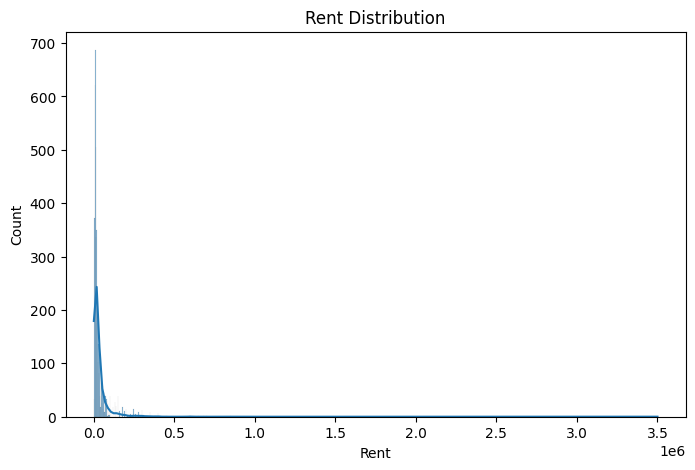

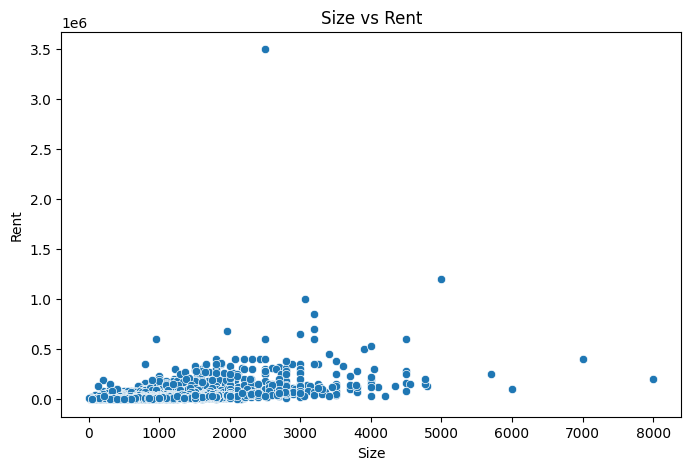

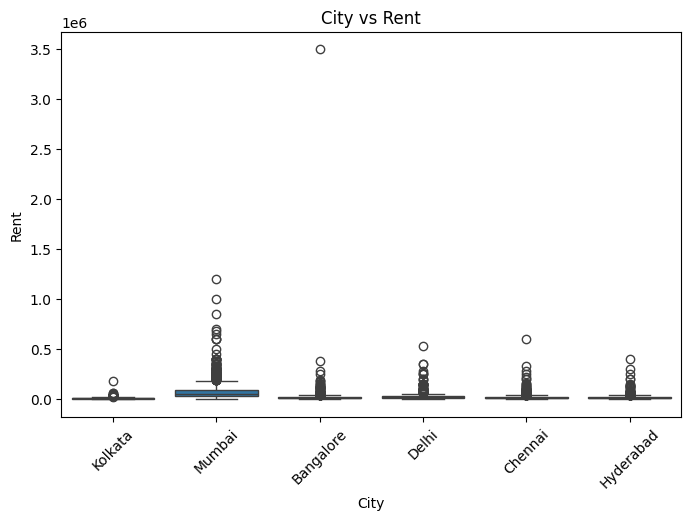

In [ ]:
# ==========================================================
# STEP 4 : DATA VISUALIZATION
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Rent distribution
plt.figure(figsize=(8,5))
sns.histplot(dataset['Rent'], kde=True)
plt.title("Rent Distribution")
plt.show()

# Size vs Rent
plt.figure(figsize=(8,5))
sns.scatterplot(x=dataset['Size'], y=dataset['Rent'])
plt.title("Size vs Rent")
plt.show()

# City vs Rent
plt.figure(figsize=(8,5))
sns.boxplot(x=dataset['City'], y=dataset['Rent'])
plt.title("City vs Rent")
plt.xticks(rotation=45)
plt.show()

# STEP 5: DATA PREPROCESSING

In this step, we will convert categorical (text) data into numerical form because machine learning models only understand numbers.

We will use Label Encoding for:
- Area Type
- City
- Furnishing Status
- Tenant Preferred
- Point of Contact (if available)

This step makes the dataset ready for training the model.

In [ ]:
# ==========================================================
# STEP 5 : DATA PREPROCESSING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convert all categorical columns into numeric
for col in dataset.select_dtypes(include='object').columns:
    dataset[col] = le.fit_transform(dataset[col])

print("Categorical columns converted into numeric format ✅")

# Show updated dataset
print("\nUpdated Dataset:")
print(dataset.head())

Categorical columns converted into numeric format ✅

Updated Dataset:
   Posted On  BHK   Rent  Size  Floor  Area Type  Area Locality  City  \
0         26    2  10000  1100    455          2            221     4   
1         21    2  20000   800     14          2           1527     4   
2         24    2  17000  1000     14          2           1760     4   
3         73    2  10000   800     10          2            526     4   
4         17    2   7500   850     10          1           1890     4   

   Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0                  2                 1         2                 2  
1                  1                 1         1                 2  
2                  1                 1         1                 2  
3                  2                 1         1                 2  
4                  2                 0         1                 2  


# STEP 6: SPLITTING DATA (TRAIN & TEST)

In this step, we will split the dataset into:

- Input Features (X)
- Target Variable (y = Rent)

Then we will divide data into:
- Training set (for model training)
- Testing set (for model evaluation)

In [ ]:
# ==========================================================
# STEP 6 : TRAIN-TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

# Target variable
y = dataset['Rent']

# Input features (remove Rent column)
X = dataset.drop('Rent', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Completed ✅")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Data Split Completed ✅
Training Data Shape: (3796, 11)
Testing Data Shape: (950, 11)


# STEP 7: MODEL TRAINING (LINEAR REGRESSION)

In this step, we will train a Machine Learning model using Linear Regression.

Linear Regression is used to predict continuous values like rent.

We will:
- Train the model using training data
- Fit the Linear Regression model
- Prepare it for predictions

In [ ]:
# ==========================================================
# STEP 7 : MODEL TRAINING
# ==========================================================

from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model Training Completed Successfully ✅")

Model Training Completed Successfully ✅


# STEP 8: MODEL PREDICTION

In this step, we will use the trained model to predict house rent values on test data.

We will compare:
- Actual Rent (y_test)
- Predicted Rent (y_pred)

In [ ]:
# ==========================================================
# STEP 8 : MODEL PREDICTION
# ==========================================================

# Predict on test data
y_pred = model.predict(X_test)

print("Predictions Completed ✅")

# Show sample predictions
print("\nActual vs Predicted (First 10 Values):")

comparison = pd.DataFrame({
    "Actual Rent": y_test.values,
    "Predicted Rent": y_pred
})

print(comparison.head(10))

Predictions Completed ✅

Actual vs Predicted (First 10 Values):
   Actual Rent  Predicted Rent
0        16000     8292.769626
1        12000    20401.811491
2        28000    37496.158082
3         8000    55016.298756
4        46000   137909.585863
5        17000    62489.106652
6        57000    72259.342744
7         9500     4376.070499
8       400000   154899.363628
9        15000    10361.861978


# STEP 9: MODEL EVALUATION

In this step, we will check how well our model is performing using evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [ ]:
# ==========================================================
# STEP 9 : MODEL EVALUATION
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Evaluation Results:
MAE : 23366.042216612088
MSE : 2145859672.865416
RMSE: 46323.42466685096
R2 Score: 0.46156728752182163


# STEP 10: PREDICTION ON NEW DATA

In this step, we will test our trained model by giving new input values.

The model will predict the house rent based on:
- BHK
- Size
- Area Type
- City
- Furnishing Status
- Tenant Preferred
- Bathroom
- Floor

In [ ]:
# ==========================================================
# STEP 10 : NEW DATA PREDICTION (FIXED)
# ==========================================================

import pandas as pd

# Empty dataframe with same columns as training data
new_data = pd.DataFrame(columns=X.columns)

# Example input (⚠️ values must match encoding
new_data.loc[0] = [2, 900, 1, 0, 1, 0, 2, 3, 0, 1, 0]

# Predict
predicted_rent = model.predict(new_data)

print("Predicted House Rent:", predicted_rent[0])

Predicted House Rent: 308959.6165494458


# CONCLUSION

In this project, we successfully built a Machine Learning model to predict house rent using Linear Regression.

We performed:
- Data loading
- Data exploration
- Visualization
- Data preprocessing
- Model training
- Prediction and evaluation

This model can help estimate rent based on different house features.